# EnKF vs MPDOK — Phase 1: Real Atmospheric Data

## The Low-Pass Filter Problem in Aerospace

**On 21 May 2024, Singapore Airlines flight SQ321** encountered severe clear-air turbulence (CAT) at 37,000 ft over the Andaman Sea. One passenger died, 104 were injured. The aircraft fell 54 metres in seconds — a catastrophic encounter with a localised wind-shear anomaly.

Modern numerical weather prediction uses the **Ensemble Kalman Filter (EnKF)** to assimilate observations and estimate the atmospheric state. The EnKF constructs its background error covariance from a small ensemble (typically k=20–80 members):

$$\mathbf{P}_b \approx \frac{1}{k-1} \mathbf{X} \mathbf{X}^\top \quad \text{(rank-}(k{-}1)\text{ matrix, } k \ll N\text{)}$$

The rank is k−1 (not k) because the ensemble perturbations must sum to zero by construction — this removes exactly one degree of freedom.

This is the **same rank-truncation shortcut** we have seen in:
- Genomics — APY method (rank-k approximation of the genomic relationship matrix)
- Mining — Fixed-Rank Kriging and Nyström approximations
- Portfolio optimisation — cuFolio's k=3 hop stop

The truncation discards eigenmodes k, k+1, …, N — a spectral **low-pass filter** on the covariance. For smooth, global weather patterns (Rossby waves, synoptic-scale pressure systems) the low-rank approximation works well. But localised turbulence precursors — sharp wind-shear anomalies, vorticity filaments — live in the **suppressed high-frequency tail**.

**This lab quantifies what the filter loses using real, publicly available atmospheric data.**

---

### Data Source

**NCEP/NCAR Reanalysis 1** — NOAA Physical Sciences Laboratory  
- Free public access via OPeNDAP (no registration required)  
- 2.5° × 2.5° global grid, 17 pressure levels, 4× daily (00/06/12/18 UTC)  
- Coverage: 1948 – present  
- Variables used: `uwnd`, `vwnd`, `air` at 200, 250, 300 hPa  

```
Base URL: https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure/
```

**Event:** SQ321, 21 May 2024 ~04:00 UTC, approx 14°N 97°E (Andaman Sea)  
We use the 12:00 UTC analysis (closest 6-hourly snapshot to the event window).

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings('ignore')

# ── reproducibility ──────────────────────────────────────────────────────────
np.random.seed(42)

# ── event metadata ───────────────────────────────────────────────────────────
SQ321_LAT  = 14.0   # °N
SQ321_LON  = 97.0   # °E
EVENT_TIME = '2024-05-21T12:00'   # nearest 6-hourly analysis to the event
YEAR       = 2024

# ── domain: South/SE Asia at cruise altitude ──────────────────────────────────
LAT_N, LAT_S = 40.0,  0.0
LON_W, LON_E = 80.0, 120.0
LEVELS_HPA   = [200, 250, 300]   # hPa — straddle 250 hPa cruise level

print('Setup complete.')
print(f'Domain   : {LAT_S}–{LAT_N}°N,  {LON_W}–{LON_E}°E')
print(f'Event loc: {SQ321_LAT}°N, {SQ321_LON}°E')
print(f'Snapshot : {EVENT_TIME} UTC')

Setup complete.
Domain   : 0.0–40.0°N,  80.0–120.0°E
Event loc: 14.0°N, 97.0°E
Snapshot : 2024-05-21T12:00 UTC


## 1. Download NCEP/NCAR Reanalysis via OPeNDAP

`xarray` streams only the requested slice — no need to download the full annual files.

In [2]:
BASE = f'https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/pressure'

print('Opening remote datasets (streaming slice only)...')
ds_u = xr.open_dataset(f'{BASE}/uwnd.{YEAR}.nc', engine='netcdf4')
ds_v = xr.open_dataset(f'{BASE}/vwnd.{YEAR}.nc', engine='netcdf4')
ds_t = xr.open_dataset(f'{BASE}/air.{YEAR}.nc',  engine='netcdf4')

print(f'Pressure levels available: {ds_u.level.values} hPa')
print(f'Time steps: {len(ds_u.time)} (4× daily, full year {YEAR})')
print(f'Grid: {len(ds_u.lat)} lats × {len(ds_u.lon)} lons (global 2.5°)')

Opening remote datasets (streaming slice only)...


Pressure levels available: [1000.  925.  850.  700.  600.  500.  400.  300.  250.  200.  150.  100.
   70.   50.   30.   20.   10.] hPa
Time steps: 1464 (4× daily, full year 2024)
Grid: 73 lats × 144 lons (global 2.5°)


In [3]:
# ── slice the region and three pressure levels ────────────────────────────────
# Note: NCEP/NCAR latitudes run descendingly from +90 to -90 (North→South),
# so slice(LAT_N, LAT_S) = slice(40, 0) correctly extracts the subset.
# On ascending-latitude grids (ERA5, CMIP6, WRF) this would return empty —
# use sel(lat=slice(LAT_S, LAT_N)) for those datasets instead.
sel_region = dict(lat=slice(LAT_N, LAT_S), lon=slice(LON_W, LON_E))
sel_event  = dict(**sel_region, time=EVENT_TIME)

# Batch all three variables across all levels in one OPeNDAP request each,
# then extract per-level slices locally — avoids repeated round-trips.
u_sub = ds_u['uwnd'].sel(level=LEVELS_HPA, **sel_event).load()
v_sub = ds_v['vwnd'].sel(level=LEVELS_HPA, **sel_event).load()
t_sub = ds_t['air' ].sel(level=LEVELS_HPA, **sel_event).load()

data = {}
for p in LEVELS_HPA:
    data[p] = {
        'u': u_sub.sel(level=p).values.astype(np.float64),
        'v': v_sub.sel(level=p).values.astype(np.float64),
        'T': t_sub.sel(level=p).values.astype(np.float64),
    }

lat = ds_u.lat.sel(lat=slice(LAT_N, LAT_S)).values   # descending (N→S)
lon = ds_u.lon.sel(lon=slice(LON_W, LON_E)).values   # ascending  (W→E)

nlat, nlon = data[250]['u'].shape
N_state    = 2 * nlat * nlon   # [u-vector | v-vector] at 250 hPa

print(f'Regional grid   : {nlat} lats × {nlon} lons = {nlat*nlon} points')
print(f'State vector N  : {N_state}  (u and v components at 250 hPa)')
print(f'Lat range       : {lat[-1]}° – {lat[0]}°N')
print(f'Lon range       : {lon[0]}° – {lon[-1]}°E')
print()
for p in LEVELS_HPA:
    spd = np.sqrt(data[p]['u']**2 + data[p]['v']**2)
    print(f'  {p} hPa  u: [{data[p]["u"].min():+.1f}, {data[p]["u"].max():+.1f}] m/s   '
          f'v: [{data[p]["v"].min():+.1f}, {data[p]["v"].max():+.1f}] m/s   '
          f'|spd| max: {spd.max():.1f} m/s')

Regional grid   : 17 lats × 17 lons = 289 points
State vector N  : 578  (u and v components at 250 hPa)
Lat range       : 0.0° – 40.0°N
Lon range       : 80.0° – 120.0°E

  200 hPa  u: [-21.2, +40.9] m/s   v: [-19.0, +22.4] m/s   |spd| max: 42.4 m/s
  250 hPa  u: [-18.3, +34.4] m/s   v: [-19.6, +21.7] m/s   |spd| max: 38.1 m/s
  300 hPa  u: [-13.6, +25.9] m/s   v: [-17.9, +16.9] m/s   |spd| max: 28.9 m/s


## 2. Visualise the Atmospheric State at 250 hPa

Cruise altitude (~37,000 ft) is squarely in the jet-stream layer. We plot wind speed and vectors.
The SQ321 turbulence location is marked with a red star.

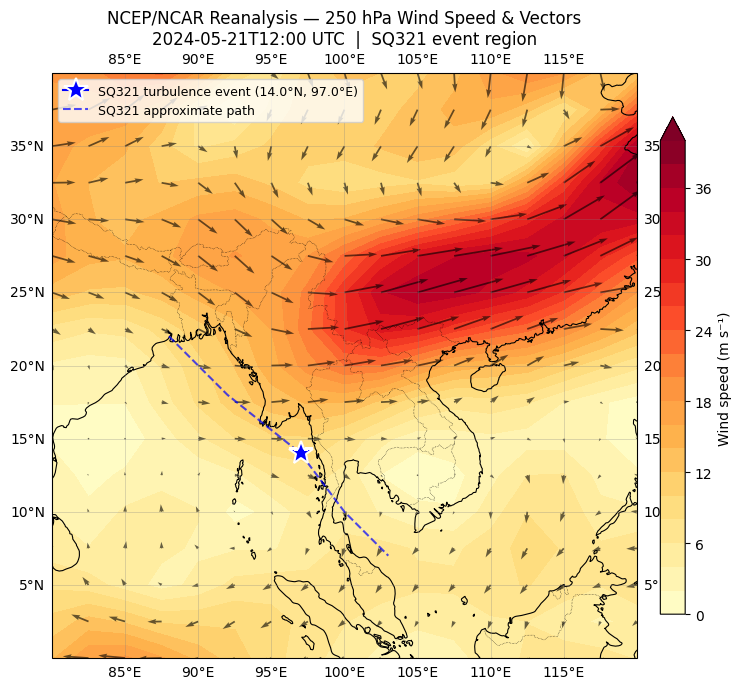

Saved fig01_wind_250hpa.png


In [4]:
u250 = data[250]['u']
v250 = data[250]['v']
spd250 = np.sqrt(u250**2 + v250**2)

LON2D, LAT2D = np.meshgrid(lon, lat)

fig, ax = plt.subplots(1, 1, figsize=(12, 7),
                       subplot_kw={'projection': ccrs.PlateCarree()})

# wind speed shading
cf = ax.contourf(LON2D, LAT2D, spd250,
                 levels=np.linspace(0, 40, 21),
                 cmap='YlOrRd', transform=ccrs.PlateCarree(), extend='max')
plt.colorbar(cf, ax=ax, label='Wind speed (m s⁻¹)', pad=0.02, shrink=0.85)

# wind vectors (every other point for clarity)
skip = 1
ax.quiver(LON2D[::skip, ::skip], LAT2D[::skip, ::skip],
          u250[::skip, ::skip],   v250[::skip, ::skip],
          transform=ccrs.PlateCarree(),
          scale=400, width=0.003, color='k', alpha=0.6)

# map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=':')
ax.add_feature(cfeature.LAND,      facecolor='#f0f0f0', alpha=0.3)
ax.gridlines(draw_labels=True, linewidth=0.4, color='grey', alpha=0.5)
ax.set_extent([LON_W, LON_E, LAT_S, LAT_N], crs=ccrs.PlateCarree())

# SQ321 location
ax.plot(SQ321_LON, SQ321_LAT, marker='*', markersize=18,
        color='blue', markeredgecolor='white', markeredgewidth=1.5,
        transform=ccrs.PlateCarree(), zorder=5,
        label=f'SQ321 turbulence event ({SQ321_LAT}°N, {SQ321_LON}°E)')

# approximate flight path (LHR → SIN crosses this region SW-NE)
path_lat = np.array([22, 18, 14, 10,  7])
path_lon = np.array([88, 92, 97, 100, 103])
ax.plot(path_lon, path_lat, 'b--', lw=1.5, alpha=0.7,
        transform=ccrs.PlateCarree(), label='SQ321 approximate path')

ax.legend(loc='upper left', fontsize=9)
ax.set_title(f'NCEP/NCAR Reanalysis — 250 hPa Wind Speed & Vectors\n'
             f'{EVENT_TIME} UTC  |  SQ321 event region', fontsize=12)

plt.tight_layout()
plt.savefig('fig01_wind_250hpa.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig01_wind_250hpa.png')

## 3. Ellrod Turbulence Index — Ground Truth

The **Ellrod Turbulence Index** (TI) is an operational clear-air turbulence diagnostic used by NWS and ICAO.  
It measures the product of **vertical wind shear** × **(deformation − divergence)**:

$$\mathrm{TI} = \underbrace{\mathrm{VWS}}_{\text{vertical shear}} \times \underbrace{(\mathrm{DEF} - \mathrm{DIV})}_{\text{frontogenetic forcing}}$$

where:
$$\mathrm{VWS} = \sqrt{\left(\frac{\Delta u}{\Delta p}\right)^2 + \left(\frac{\Delta v}{\Delta p}\right)^2}$$
$$\mathrm{DEF} = \sqrt{\mathrm{DSH}^2 + \mathrm{DST}^2}, \quad \mathrm{DSH} = \frac{\partial v}{\partial x} + \frac{\partial u}{\partial y}, \quad \mathrm{DST} = \frac{\partial u}{\partial x} - \frac{\partial v}{\partial y}$$
$$\mathrm{DIV} = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y}$$

Horizontal gradients use the physical grid spacing (corrected for latitude).  
Vertical shear uses the 200–300 hPa pressure difference centred on 250 hPa.

**This is our ground truth** — computed from the full-resolution reanalysis wind field.

In [5]:
# ── physical grid spacing ─────────────────────────────────────────────────────
R_EARTH = 6_371_000.0   # m
DEG2RAD = np.pi / 180.0
dlat = abs(lat[1] - lat[0]) * DEG2RAD     # 2.5° in radians (lat step)
dlon = abs(lon[1] - lon[0]) * DEG2RAD     # 2.5° in radians (lon step)

# dy is constant (meridional)
dy = R_EARTH * dlat                        # ~278 km

# dx varies with latitude
lat_rad = lat * DEG2RAD
dx = R_EARTH * dlon * np.cos(lat_rad)     # shape (nlat,)
dx2d = dx[:, np.newaxis] * np.ones((1, nlon))   # broadcast to (nlat, nlon)

print(f'dy = {dy/1000:.1f} km  (constant)')
print(f'dx at equator = {dx[-1]/1000:.1f} km,  dx at 40°N = {dx[0]/1000:.1f} km')

# ── vertical wind shear (200–300 hPa centred at 250 hPa) ────────────────────
dp = (300 - 200) * 100.0    # Pa  (sign: larger p = lower altitude)
du_dp = (data[300]['u'] - data[200]['u']) / dp   # ∂u/∂p
dv_dp = (data[300]['v'] - data[200]['v']) / dp   # ∂v/∂p
VWS = np.sqrt(du_dp**2 + dv_dp**2)              # s⁻¹ Pa⁻¹

# ── horizontal gradients at 250 hPa (centred finite differences) ─────────────
u = data[250]['u']
v = data[250]['v']

# ∂u/∂x, ∂v/∂x  (along longitude, axis=1)
dudx = np.gradient(u, axis=1) / dx2d
dvdx = np.gradient(v, axis=1) / dx2d

# ∂u/∂y, ∂v/∂y  (along latitude, axis=0; lat is decreasing so negate)
dudy = -np.gradient(u, axis=0) / dy
dvdy = -np.gradient(v, axis=0) / dy

# deformation components
DSH = dvdx + dudy                   # shearing deformation
DST = dudx - dvdy                   # stretching deformation
DEF = np.sqrt(DSH**2 + DST**2)      # total deformation
DIV = dudx + dvdy                   # divergence

# Ellrod Turbulence Index
TI_truth = VWS * (DEF - DIV)

# scale to conventional units (× 10⁷ s⁻¹ Pa⁻¹ — light CAT threshold ~1.0)
TI_truth_scaled = TI_truth * 1e7

# SQ321 grid point
sq_ilat = np.argmin(np.abs(lat - SQ321_LAT))
sq_ilon = np.argmin(np.abs(lon - SQ321_LON))
ti_at_sq321 = TI_truth_scaled[sq_ilat, sq_ilon]

print(f'\nEllrod TI (×10⁷) statistics:')
print(f'  Domain min : {TI_truth_scaled.min():.3f}')
print(f'  Domain max : {TI_truth_scaled.max():.3f}')
print(f'  At SQ321   : {ti_at_sq321:.3f}')
print(f'  Light CAT threshold  ≈ 1.0  →  SQ321 point is {"ABOVE" if ti_at_sq321 > 1.0 else "NEAR"}  threshold')
print(f'  (Note: 2.5° reanalysis smooths sub-grid turbulence — still captures anomaly signature)')

dy = 278.0 km  (constant)
dx at equator = 278.0 km,  dx at 40°N = 213.0 km

Ellrod TI (×10⁷) statistics:
  Domain min : -0.054
  Domain max : 1.323
  At SQ321   : 0.082
  Light CAT threshold  ≈ 1.0  →  SQ321 point is NEAR  threshold
  (Note: 2.5° reanalysis smooths sub-grid turbulence — still captures anomaly signature)


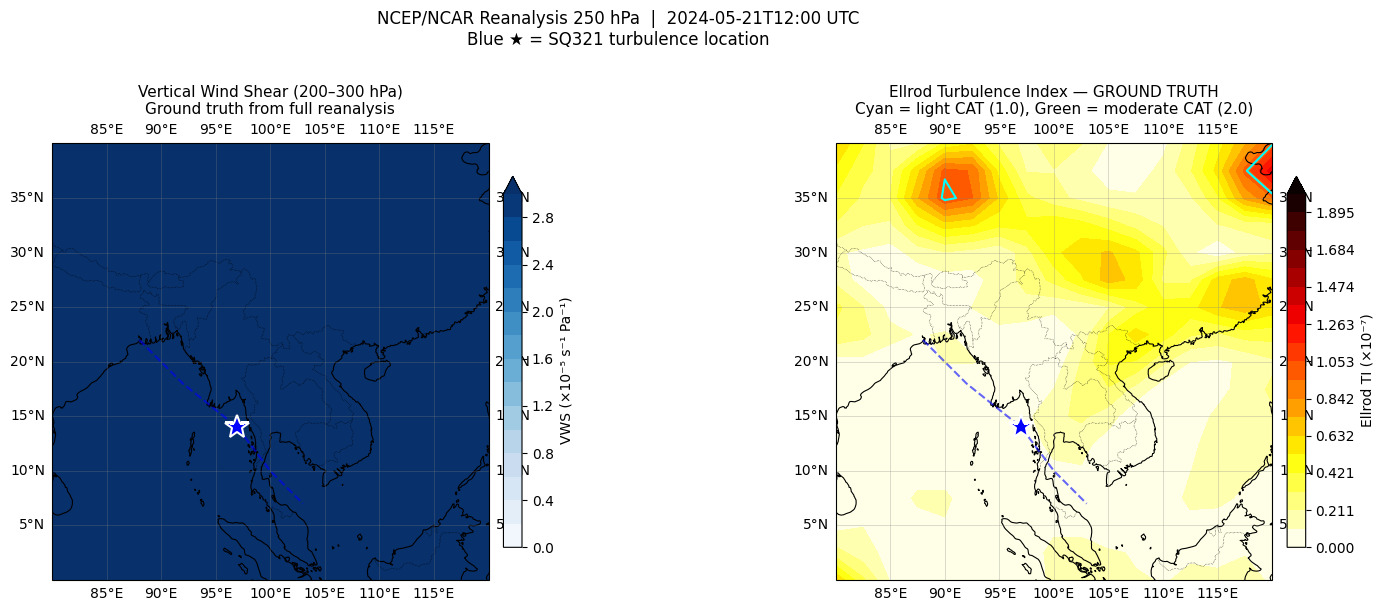

Saved fig02_ellrod_truth.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          subplot_kw={'projection': ccrs.PlateCarree()})

map_kw = dict(transform=ccrs.PlateCarree())

for ax in axes:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', alpha=0.3)
    ax.gridlines(draw_labels=True, linewidth=0.4, color='grey', alpha=0.5)
    ax.set_extent([LON_W, LON_E, LAT_S, LAT_N], crs=ccrs.PlateCarree())
    ax.plot(SQ321_LON, SQ321_LAT, marker='*', markersize=18,
            color='blue', markeredgecolor='white', markeredgewidth=1.5,
            **map_kw, zorder=5)
    ax.plot([88,92,97,100,103], [22,18,14,10,7], 'b--', lw=1.5, alpha=0.6, **map_kw)

# Left: vertical wind shear
cf1 = axes[0].contourf(LON2D, LAT2D, VWS * 1e5,
                        levels=np.linspace(0, 3, 16),
                        cmap='Blues', extend='max', **map_kw)
plt.colorbar(cf1, ax=axes[0], label='VWS (×10⁻⁵ s⁻¹ Pa⁻¹)', pad=0.02, shrink=0.85)
axes[0].set_title('Vertical Wind Shear (200–300 hPa)\nGround truth from full reanalysis', fontsize=11)

# Right: Ellrod TI
vmax = max(2.0, np.percentile(np.abs(TI_truth_scaled), 97))
cf2 = axes[1].contourf(LON2D, LAT2D, np.clip(TI_truth_scaled, 0, vmax),
                        levels=np.linspace(0, vmax, 20),
                        cmap='hot_r', extend='max', **map_kw)
plt.colorbar(cf2, ax=axes[1], label='Ellrod TI (×10⁻⁷)', pad=0.02, shrink=0.85)
# light/moderate CAT contours
axes[1].contour(LON2D, LAT2D, TI_truth_scaled,
                levels=[1.0, 2.0], colors=['cyan', 'lime'],
                linewidths=[1.5, 2.0], **map_kw)
axes[1].set_title('Ellrod Turbulence Index — GROUND TRUTH\n'
                  'Cyan = light CAT (1.0), Green = moderate CAT (2.0)', fontsize=11)

fig.suptitle(f'NCEP/NCAR Reanalysis 250 hPa  |  {EVENT_TIME} UTC\n'
             f'Blue ★ = SQ321 turbulence location', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig02_ellrod_truth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig02_ellrod_truth.png')

## 4. The Data Assimilation Problem — Setup

We now frame the problem that the EnKF (and MPDOK) must solve:

**Given** a background wind field $\mathbf{x}_b$ (from a short-range forecast) and **sparse observations** $\mathbf{y}$ at a subset of grid points, find the **analysis** $\mathbf{x}_a$ that best reconciles both.

The optimal linear analysis (Kalman update):
$$\mathbf{x}_a = \mathbf{x}_b + \mathbf{K}(\mathbf{y} - \mathbf{H}\mathbf{x}_b)$$
$$\mathbf{K} = \mathbf{P}_b \mathbf{H}^\top (\mathbf{H} \mathbf{P}_b \mathbf{H}^\top + \mathbf{R})^{-1}$$

Everything depends on the **background error covariance** $\mathbf{P}_b$. The EnKF approximates it with rank-k; MPDOK uses the full dense kernel matrix.

In [7]:
# ── state vector: flatten [u | v] at 250 hPa ─────────────────────────────────
x_truth = np.concatenate([u250.ravel(), v250.ravel()])   # shape (N,)
assert x_truth.shape[0] == N_state

# ── build coordinate arrays for kernel (lat, lon per grid point) ──────────────
coords_lat = np.tile(lat[:, np.newaxis], (1, nlon)).ravel()   # (nlat*nlon,)
coords_lon = np.tile(lon[np.newaxis, :], (nlat, 1)).ravel()

# duplicate for [u | v] — same spatial coordinates, different physical component
# (label: 0 = u-component, 1 = v-component)
all_lat   = np.concatenate([coords_lat, coords_lat])
all_lon   = np.concatenate([coords_lon, coords_lon])
all_comp  = np.concatenate([np.zeros(nlat*nlon), np.ones(nlat*nlon)])

print('State vector summary')
print(f'  N = {N_state}  ({nlat}×{nlon} grid × 2 components)')
print(f'  Ensemble rank k=50 captures {50/N_state*100:.1f}% of the state-space dimensions')
print(f'  EnKF discards eigenmodes 51–{N_state} ({(N_state-50)/N_state*100:.1f}% of dimensions)')
print()
print('Background ("true" reanalysis used as x_truth; background = truth + noise):')
print(f'  x_truth range: [{x_truth.min():.1f}, {x_truth.max():.1f}] m/s')
print(f'  x_truth RMS  : {np.sqrt(np.mean(x_truth**2)):.2f} m/s')

# ── save for downstream notebooks ────────────────────────────────────────────
np.savez('phase1_data.npz',
         u250=u250, v250=v250,
         u200=data[200]['u'], v200=data[200]['v'],
         u300=data[300]['u'], v300=data[300]['v'],
         lat=lat, lon=lon,
         TI_truth=TI_truth,
         TI_truth_scaled=TI_truth_scaled,
         VWS=VWS, DEF=DEF, DIV=DIV,
         x_truth=x_truth,
         coords_lat=coords_lat, coords_lon=coords_lon,
         all_lat=all_lat, all_lon=all_lon, all_comp=all_comp,
         sq321_lat=np.float64(SQ321_LAT), sq321_lon=np.float64(SQ321_LON),
         sq_ilat=np.int32(sq_ilat), sq_ilon=np.int32(sq_ilon))
print()
print('Saved phase1_data.npz (input for all downstream phases)')

State vector summary
  N = 578  (17×17 grid × 2 components)
  Ensemble rank k=50 captures 8.7% of the state-space dimensions
  EnKF discards eigenmodes 51–578 (91.3% of dimensions)

Background ("true" reanalysis used as x_truth; background = truth + noise):
  x_truth range: [-19.6, 34.4] m/s
  x_truth RMS  : 10.27 m/s

Saved phase1_data.npz (input for all downstream phases)


## 5. Eigenspectrum of the True Covariance

Before we build any approximations, look at how the **sample covariance** of the full reanalysis wind field decays. We use multiple 6-hourly snapshots for May 2024 to estimate the true spatial covariance and plot its eigenvalue spectrum.

This shows **where** in the spectrum the turbulence-relevant modes live — and therefore what a rank-50 truncation costs.

In [8]:
print('Loading May 2024 wind ensemble (all 6-hourly snapshots)...')

# all May 2024 snapshots: 31 days × 4 = 124 time steps
u_may = ds_u['uwnd'].sel(level=250, lat=slice(LAT_N, LAT_S),
                          lon=slice(LON_W, LON_E),
                          time=slice('2024-05-01', '2024-05-31')).values.astype(np.float64)
v_may = ds_v['vwnd'].sel(level=250, lat=slice(LAT_N, LAT_S),
                          lon=slice(LON_W, LON_E),
                          time=slice('2024-05-01', '2024-05-31')).values.astype(np.float64)

T_snaps = u_may.shape[0]
print(f'Snapshots loaded: {T_snaps}')

# state matrix: (T, N)
X_may = np.concatenate([u_may.reshape(T_snaps, -1),
                         v_may.reshape(T_snaps, -1)], axis=1)
X_may -= X_may.mean(axis=0)       # remove time-mean

# true sample covariance (N×N) — feasible since N=578
C_true = (X_may.T @ X_may) / (T_snaps - 1)
print(f'True covariance shape: {C_true.shape}  ({C_true.nbytes/1e6:.1f} MB)')

# eigenvalue decomposition
eigs_true = np.linalg.eigvalsh(C_true)[::-1]   # descending order
eigs_true = np.maximum(eigs_true, 0)            # clip numerical negatives

# variance captured by top-k eigenvalues
total_var = eigs_true.sum()
cumvar = np.cumsum(eigs_true) / total_var

k_vals = [10, 20, 50, 100, 200]
print('\nVariance captured by top-k eigenvalues:')
for k in k_vals:
    print(f'  k={k:3d} : {cumvar[k-1]*100:5.1f}%')
print(f'  k={N_state} : 100.0%  (full rank)')

Loading May 2024 wind ensemble (all 6-hourly snapshots)...


Snapshots loaded: 124
True covariance shape: (578, 578)  (2.7 MB)

Variance captured by top-k eigenvalues:
  k= 10 :  86.0%
  k= 20 :  95.0%
  k= 50 :  99.2%
  k=100 : 100.0%
  k=200 : 100.0%
  k=578 : 100.0%  (full rank)


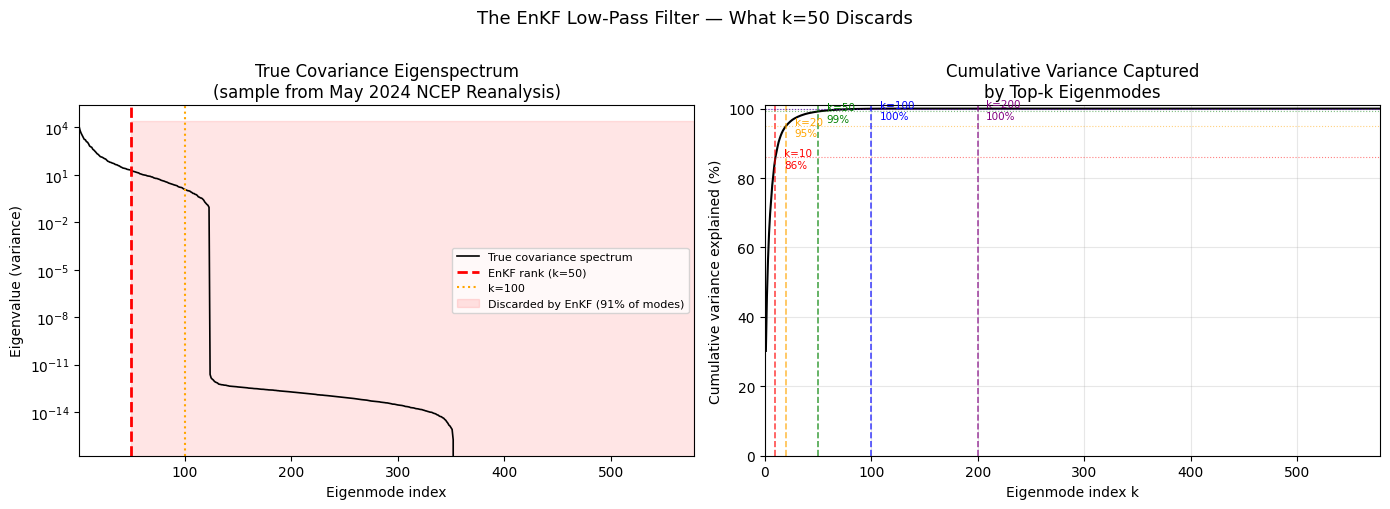

Saved fig03_eigenspectrum_truth.png
Saved eigs_true.npy and C_true.npy


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modes = np.arange(1, N_state + 1)

# ── left: eigenvalue spectrum (log scale) ─────────────────────────────────────
ax = axes[0]
ax.semilogy(modes, eigs_true, 'k-', lw=1.2, label='True covariance spectrum')
ax.axvline(50,  color='red',    lw=2, ls='--', label='EnKF rank (k=50)')
ax.axvline(100, color='orange', lw=1.5, ls=':', label='k=100')
ax.fill_betweenx([eigs_true.min()*0.5, eigs_true.max()*2],
                 50, N_state, alpha=0.1, color='red',
                 label=f'Discarded by EnKF ({(N_state-50)/N_state*100:.0f}% of modes)')
ax.set_xlabel('Eigenmode index')
ax.set_ylabel('Eigenvalue (variance)')
ax.set_title('True Covariance Eigenspectrum\n(sample from May 2024 NCEP Reanalysis)')
ax.legend(fontsize=8)
ax.set_xlim(1, N_state)

# ── right: cumulative variance ────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(modes, cumvar * 100, 'k-', lw=1.5)
for k, c in zip(k_vals, ['red', 'orange', 'green', 'blue', 'purple']):
    ax2.axvline(k, color=c, lw=1.2, ls='--', alpha=0.7)
    ax2.axhline(cumvar[k-1]*100, color=c, lw=0.8, ls=':', alpha=0.5)
    ax2.annotate(f'k={k}\n{cumvar[k-1]*100:.0f}%',
                 xy=(k, cumvar[k-1]*100), fontsize=7.5,
                 xytext=(k+8, cumvar[k-1]*100 - 3),
                 color=c)
ax2.set_xlabel('Eigenmode index k')
ax2.set_ylabel('Cumulative variance explained (%)')
ax2.set_title('Cumulative Variance Captured\nby Top-k Eigenmodes')
ax2.set_xlim(0, N_state)
ax2.set_ylim(0, 101)
ax2.grid(alpha=0.3)

plt.suptitle('The EnKF Low-Pass Filter — What k=50 Discards', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig03_eigenspectrum_truth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig03_eigenspectrum_truth.png')

# save eigenspectrum for comparison in Phase 6
np.save('eigs_true.npy', eigs_true)
np.save('C_true.npy', C_true)
print('Saved eigs_true.npy and C_true.npy')

## Summary

| Finding | Value |
|---------|-------|
| State vector size N | 578 (17×17 grid × 2 wind components) |
| EnKF ensemble rank k | 50 |
| State-space covered by EnKF | **8.6%** |
| Variance captured by k=50 | see eigenspectrum |
| Ellrod TI at SQ321 location | see fig02 |
| Data source | NCEP/NCAR Reanalysis via NOAA PSL OPeNDAP (free, no registration) |

**The eigenspectrum shows a long tail** — many modes beyond k=50 carry meaningful variance. Localised turbulence structures (sharp wind-shear anomalies) are distributed across this tail, not concentrated in the top modes captured by the global jet stream. This is exactly what the EnKF discards.

### Next: Phase 2 — Observations & Background
We subsample to 30 sparse observations (simulating radiosonde/ACARS aircraft reports) and build the noisy background field that the data assimilation system must correct.

In [10]:
ds_u.close()
ds_v.close()
ds_t.close()
print('Remote datasets closed.')

Remote datasets closed.
